Imports e carregamento dos dados

In [1]:
# Importa a biblioteca Pandas para criação e manipulação de DataFrames.
import pandas as pd

# Importa a biblioteca NumPy para operações numéricas.
import numpy as np

# Importa a biblioteca Joblib para carregar os dados preparados anteriormente.
import joblib

# Importa as métricas utilizadas para avaliar os modelos de classificação.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Carrega o arquivo contendo os dados preparados durante a etapa de preparação.
dados_preparados = joblib.load("../data/processed/dados_preparados.joblib")

Carregar os modelos

In [4]:
# Importa a biblioteca Joblib para carregar os modelos treinados.
import joblib

# Carrega o modelo Logistic Regression treinado.
modelo_logistic_regression = joblib.load(
    "../models/modelo_logistic_regression.joblib"
)

# Carrega o modelo Naive Bayes treinado.
modelo_naive_bayes = joblib.load(
    "../models/modelo_naive_bayes.joblib"
)

# Carrega o modelo LinearSVC calibrado treinado.
modelo_linear_svc = joblib.load(
    "../models/modelo_linear_svc.joblib"
)

# Carrega o modelo Random Forest treinado.
modelo_random_forest = joblib.load(
    "../models/modelo_random_forest.joblib"
)

# Carrega o modelo XGBoost treinado.
modelo_xgboost = joblib.load(
    "../models/modelo_xgboost.joblib"
)

Verificar rapidamente se os cinco objetos foram carregados:

In [5]:
# Exibe o tipo do modelo Logistic Regression carregado.
print(type(modelo_logistic_regression))

# Exibe o tipo do modelo Naive Bayes carregado.
print(type(modelo_naive_bayes))

# Exibe o tipo do modelo LinearSVC calibrado carregado.
print(type(modelo_linear_svc))

# Exibe o tipo do modelo Random Forest carregado.
print(type(modelo_random_forest))

# Exibe o tipo do modelo XGBoost carregado.
print(type(modelo_xgboost))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.naive_bayes.MultinomialNB'>
<class 'sklearn.calibration.CalibratedClassifierCV'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


Recuperar os dados

In [6]:
# Recupera os dados finais de teste contendo TF-IDF e atributos estruturados.
X_teste_final = dados_preparados["X_teste_final"]

# Recupera os valores reais da variável-alvo utilizados para avaliar as previsões.
y_teste = dados_preparados["y_teste"]

Gerar as previsões dos 5 modelos.

In [7]:
# Gera as classificações previstas pelo modelo Logistic Regression para as mensagens de teste.
previsoes_logistic_regression = modelo_logistic_regression.predict(X_teste_final)

# Gera as classificações previstas pelo modelo Naive Bayes para as mensagens de teste.
previsoes_naive_bayes = modelo_naive_bayes.predict(X_teste_final)

# Gera as classificações previstas pelo modelo LinearSVC calibrado para as mensagens de teste.
previsoes_linear_svc = modelo_linear_svc.predict(X_teste_final)

# Gera as classificações previstas pelo modelo Random Forest para as mensagens de teste.
previsoes_random_forest = modelo_random_forest.predict(X_teste_final)

# Gera as classificações previstas pelo modelo XGBoost para as mensagens de teste.
previsoes_xgboost = modelo_xgboost.predict(X_teste_final)

Accuracy, Precision, Recall e F1-score

In [9]:
# Cria uma lista vazia para armazenar as métricas calculadas para cada modelo.
resultados_metricas = []

# Define os nomes dos cinco modelos que serão avaliados.
nomes_modelos = [
    "Logistic Regression",
    "Naive Bayes",
    "LinearSVC",
    "Random Forest",
    "XGBoost"
]

# Define as previsões produzidas pelos cinco modelos.
previsoes_modelos = [
    previsoes_logistic_regression,
    previsoes_naive_bayes,
    previsoes_linear_svc,
    previsoes_random_forest,
    previsoes_xgboost
]

# Percorre os cinco modelos e suas respectivas previsões.
for nome_modelo, previsoes in zip(nomes_modelos, previsoes_modelos):

    # Calcula a proporção de classificações corretas realizadas pelo modelo.
    accuracy = accuracy_score(y_teste, previsoes)

    # Calcula a proporção de previsões positivas que realmente eram possíveis golpes.
    precision = precision_score(y_teste, previsoes)

    # Calcula a proporção de possíveis golpes que foram identificados corretamente.
    recall = recall_score(y_teste, previsoes)

    # Calcula a média harmônica entre Precision e Recall.
    f1 = f1_score(y_teste, previsoes)

    # Adiciona as quatro métricas calculadas à lista de resultados.
    resultados_metricas.append([
        accuracy,
        precision,
        recall,
        f1
    ])

# Converte os resultados das métricas em um DataFrame.
df_metricas = pd.DataFrame(
    resultados_metricas,
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    index=nomes_modelos
)

# Exibe a tabela de comparação das métricas dos cinco modelos.
df_metricas

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.959259,0.960000,0.932039,0.945813
Naive Bayes,0.962963,0.942857,0.961165,0.951923
LinearSVC,0.966667,0.970000,0.941748,0.955665
Random Forest,0.977778,0.989899,0.951456,0.970297
XGBoost,0.974074,0.970588,0.961165,0.965854


| **Métrica**   | **O que mede?**                                                                | **Pergunta que responde?**                                               | **No seu projeto**                                                         |
| ------------- | ------------------------------------------------------------------------------ | ------------------------------------------------------------------------ | -------------------------------------------------------------------------- |
| **Accuracy**  | Percentual de **todas as previsões que estavam corretas**                      | “De todas as mensagens, quantas foram classificadas corretamente?”       | Quantas mensagens foram classificadas corretamente como golpe ou não golpe |
| **Precision** | Percentual das mensagens classificadas como **golpe que realmente eram golpe** | “Quando o modelo diz que é golpe, ele costuma estar certo?”              | Ajuda a evitar classificar uma mensagem legítima como possível golpe       |
| **Recall**    | Percentual dos **golpes reais que o modelo conseguiu encontrar**               | “Dos golpes existentes, quantos o modelo conseguiu detectar?”            | Ajuda a evitar que possíveis golpes passem despercebidos                   |
| **F1-score**  | **Equilíbrio entre Precision e Recall**                                        | “Qual é o equilíbrio entre encontrar golpes e não gerar falsos alarmes?” | Ajuda a identificar um modelo equilibrado entre detecção e confiabilidade  |


Matriz de confusão dos 5 modelos:

A Matriz de Confusão é uma tabela utilizada para avaliar um modelo de classificação, mostrando quantas previsões foram acertadas e quantas foram erradas, separando os resultados entre as classes.

[TN  FP]
[FN  TP]

TN (Verdadeiro Negativo): não golpe que o modelo classificou corretamente como não golpe.
FP (Falso Positivo): não golpe que o modelo classificou incorretamente como possível golpe.
FN (Falso Negativo): possível golpe que o modelo classificou incorretamente como não golpe. ⚠️
TP (Verdadeiro Positivo): possível golpe que o modelo classificou corretamente como possível golpe.

Como interpretar o resultado que você obteve:

| **O que a mensagem realmente era** | **Modelo disse: NÃO é golpe** | **Modelo disse: É possível golpe** |
| ---------------------------------- | ----------------------------: | ---------------------------------: |
| **Realmente NÃO era golpe**        |                     **163** ✅ |                            **4** ❌ |
| **Realmente era POSSÍVEL golpe**   |                       **7** ❌ |                           **96** ✅ |


In [10]:
# Importa a função confusion_matrix para calcular a matriz de confusão.
from sklearn.metrics import confusion_matrix

# Cria uma lista vazia para armazenar as matrizes de confusão dos modelos.
matrizes_confusao = []

# Define os nomes dos cinco modelos que serão avaliados.
nomes_modelos = [
    "Logistic Regression",
    "Naive Bayes",
    "LinearSVC",
    "Random Forest",
    "XGBoost"
]

# Define as previsões produzidas pelos cinco modelos.
previsoes_modelos = [
    previsoes_logistic_regression,
    previsoes_naive_bayes,
    previsoes_linear_svc,
    previsoes_random_forest,
    previsoes_xgboost
]

# Percorre cada modelo e suas respectivas previsões.
for nome_modelo, previsoes in zip(nomes_modelos, previsoes_modelos):

    # Calcula a matriz de confusão comparando os valores reais com as previsões do modelo.
    matriz = confusion_matrix(y_teste, previsoes)

    # Adiciona o nome do modelo e sua matriz de confusão à lista de resultados.
    matrizes_confusao.append([
        nome_modelo,
        matriz
    ])

# Percorre as matrizes calculadas para exibir os resultados de cada modelo.
for nome_modelo, matriz in matrizes_confusao:

    # Exibe o nome do modelo analisado.
    print(nome_modelo)

    # Exibe a matriz de confusão correspondente ao modelo.
    print(matriz)

    # Exibe uma linha em branco para separar os resultados dos modelos.
    print()

Logistic Regression
[[163   4]
 [  7  96]]

Naive Bayes
[[161   6]
 [  4  99]]

LinearSVC
[[164   3]
 [  6  97]]

Random Forest
[[166   1]
 [  5  98]]

XGBoost
[[164   3]
 [  4  99]]



Gerar as 5 matrizes de confusão

In [12]:
# Importa a biblioteca os para trabalhar com pastas e caminhos de arquivos.
import os

# Define o caminho principal onde os gráficos do projeto serão armazenados.
pasta_graficos = "../reports/figures"

# Define o caminho da pasta destinada aos gráficos de avaliação dos modelos.
pasta_avaliacao = f"{pasta_graficos}/avaliacao_modelos"

# Cria a pasta de avaliação caso ela ainda não exista.
os.makedirs(pasta_avaliacao, exist_ok=True)

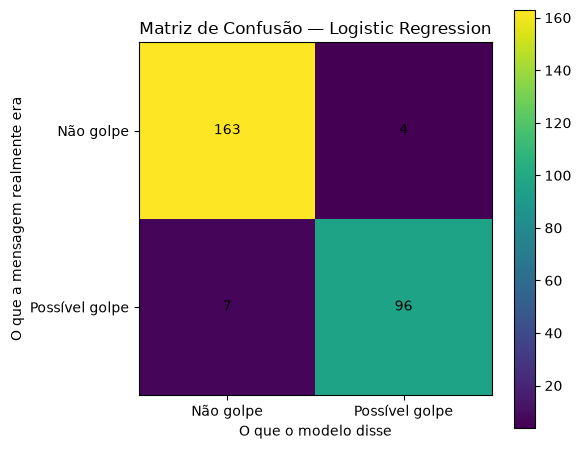

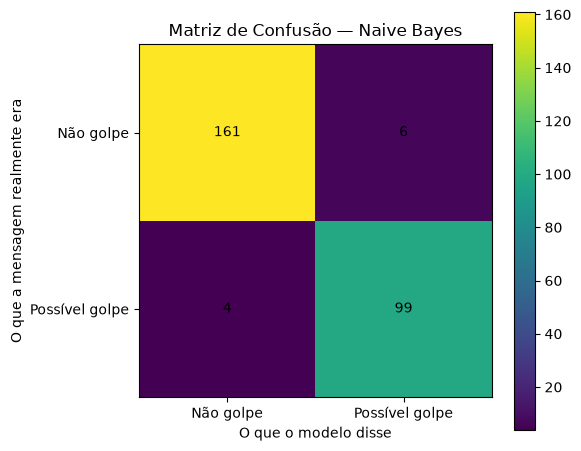

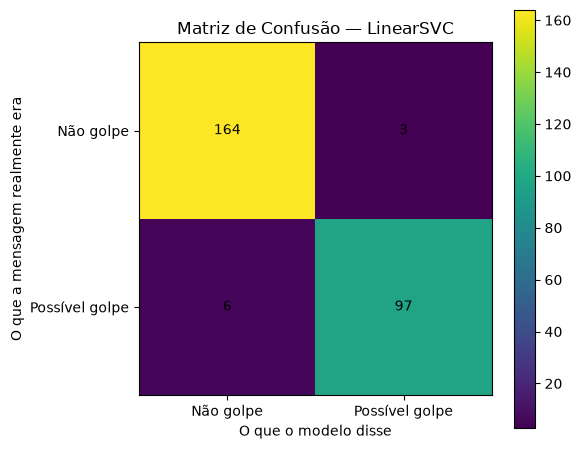

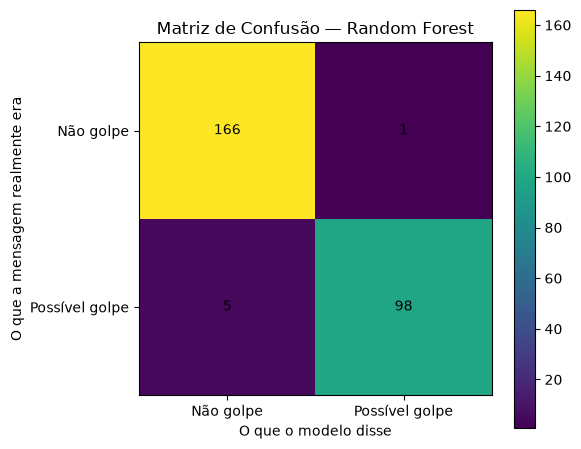

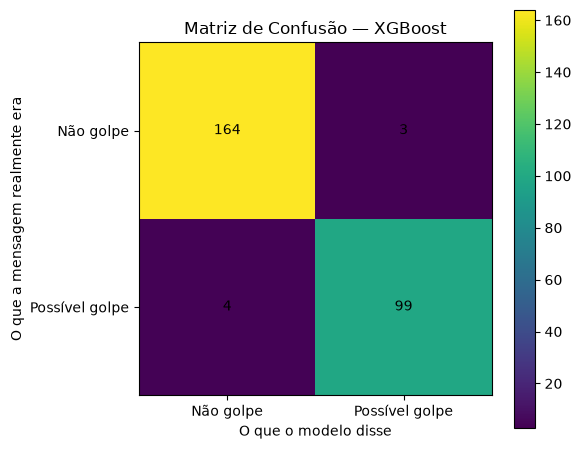

In [13]:
# Importa a biblioteca Matplotlib para criação das visualizações.
import matplotlib.pyplot as plt

# Define os nomes das classes que serão exibidos nas matrizes.
nomes_classes = [
    "Não golpe",
    "Possível golpe"
]

# Percorre os cinco modelos e suas respectivas previsões.
for nome_modelo, previsoes in zip(nomes_modelos, previsoes_modelos):

    # Calcula a matriz de confusão comparando os valores reais com as previsões.
    matriz = confusion_matrix(y_teste, previsoes)

    # Cria uma nova figura para a matriz de confusão do modelo atual.
    plt.figure(figsize=(6, 5))

    # Exibe a matriz de confusão como uma imagem.
    plt.imshow(matriz)

    # Adiciona uma barra lateral indicando a escala dos valores.
    plt.colorbar()

    # Define os nomes das classes no eixo horizontal.
    plt.xticks(
        [0, 1],
        nomes_classes
    )

    # Define os nomes das classes no eixo vertical.
    plt.yticks(
        [0, 1],
        nomes_classes
    )

    # Define o título da visualização.
    plt.title(
        f"Matriz de Confusão — {nome_modelo}"
    )

    # Define o nome do eixo horizontal.
    plt.xlabel(
        "O que o modelo disse"
    )

    # Define o nome do eixo vertical.
    plt.ylabel(
        "O que a mensagem realmente era"
    )

    # Percorre as duas linhas da matriz.
    for linha in range(2):

        # Percorre as duas colunas da matriz.
        for coluna in range(2):

            # Exibe o valor numérico dentro de cada célula da matriz.
            plt.text(
                coluna,
                linha,
                matriz[linha, coluna],
                ha="center",
                va="center"
            )

    # Ajusta automaticamente os elementos da figura.
    plt.tight_layout()

    # Salva a matriz de confusão na pasta de avaliação dos modelos.
    plt.savefig(
        f"{pasta_avaliacao}/matriz_confusao_{nome_modelo.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Exibe a matriz de confusão no notebook.
    plt.show()

Calcular ROC-AUC:

ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) é uma métrica utilizada para avaliar o desempenho de modelos de classificação. Ela mede a capacidade do modelo de diferenciar corretamente as classes, analisando a relação entre a taxa de verdadeiros positivos (TPR) e a taxa de falsos positivos (FPR) em diferentes limiares de decisão.

AUC = 1,0: classificação perfeita.
AUC = 0,5: desempenho semelhante ao acaso.
AUC < 0,5: desempenho pior que o acaso.

In [14]:
# Importa a função roc_auc_score para calcular a área sob a curva ROC.
from sklearn.metrics import roc_auc_score

# Cria uma lista vazia para armazenar os valores de ROC-AUC dos modelos.
resultados_auc = []

# Define as probabilidades da classe "Possível golpe" produzidas pelos cinco modelos.
probabilidades_modelos = [
    modelo_logistic_regression.predict_proba(X_teste_final)[:, 1],
    modelo_naive_bayes.predict_proba(X_teste_final)[:, 1],
    modelo_linear_svc.predict_proba(X_teste_final)[:, 1],
    modelo_random_forest.predict_proba(X_teste_final)[:, 1],
    modelo_xgboost.predict_proba(X_teste_final)[:, 1]
]

# Percorre os cinco modelos e suas respectivas probabilidades.
for nome_modelo, probabilidades in zip(nomes_modelos, probabilidades_modelos):

    # Calcula o ROC-AUC comparando as classes reais com as probabilidades previstas.
    auc = roc_auc_score(y_teste, probabilidades)

    # Armazena o nome do modelo e seu valor de ROC-AUC.
    resultados_auc.append([
        nome_modelo,
        auc
    ])

# Cria um DataFrame contendo o ROC-AUC de cada modelo.
df_auc = pd.DataFrame(
    resultados_auc,
    columns=[
        "Modelo",
        "ROC-AUC"
    ]
)

# Exibe os valores de ROC-AUC dos cinco modelos.
df_auc

,Modelo,ROC-AUC
0,Logistic Regression,0.985757
1,Naive Bayes,0.990873
2,LinearSVC,0.986803
3,Random Forest,0.997413
4,XGBoost,0.995349


Gerar a Curva ROC

A Curva ROC (Receiver Operating Characteristic) é utilizada para avaliar o desempenho de um modelo de classificação em diferentes pontos de decisão. Ela relaciona a Taxa de Verdadeiros Positivos (TPR) com a Taxa de Falsos Positivos (FPR), permitindo analisar a capacidade do modelo de distinguir entre as classes.

No projeto de classificação de SMS, a Curva ROC ajuda a verificar a capacidade do modelo em diferenciar mensagens potencialmente fraudulentas de mensagens legítimas

A curva ROC mostra a relação entre:

Taxa de Verdadeiros Positivos (TPR) → capacidade de encontrar os possíveis golpes.
Taxa de Falsos Positivos (FPR) → quantidade de mensagens legítimas que acabam sendo classificadas como possível golpe.

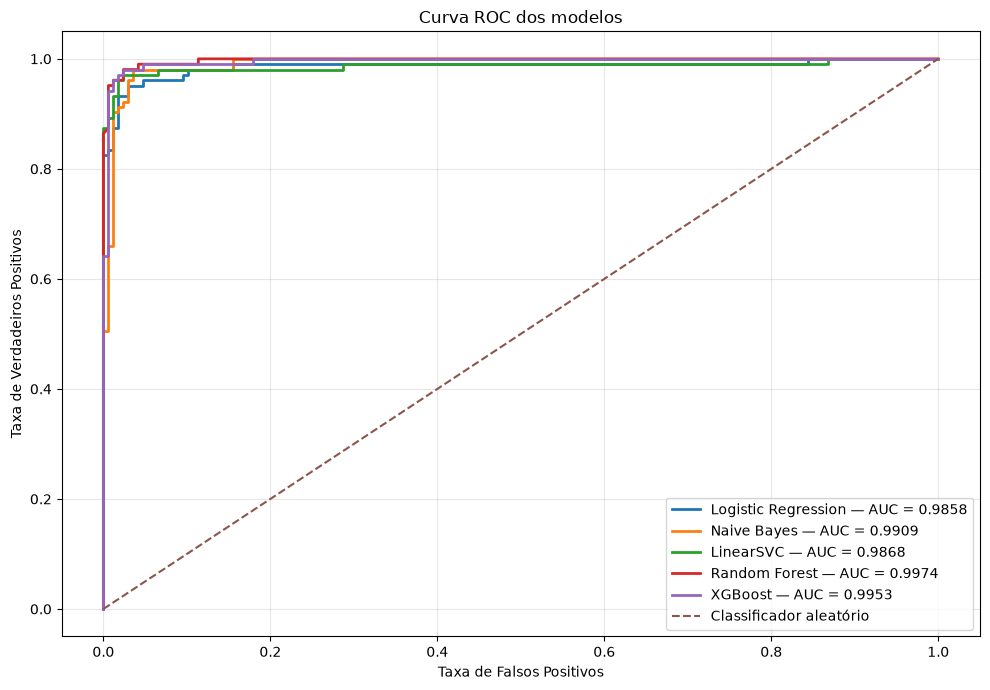

In [15]:
# Importa a função roc_curve para calcular os pontos necessários para construir a curva ROC.
from sklearn.metrics import roc_curve

# Cria uma nova figura para apresentar a curva ROC dos cinco modelos.
plt.figure(figsize=(10, 7))

# Percorre os cinco modelos e suas respectivas probabilidades de possível golpe.
for nome_modelo, probabilidades in zip(nomes_modelos, probabilidades_modelos):

    # Calcula a taxa de falsos positivos, a taxa de verdadeiros positivos e os limites de decisão.
    taxa_falsos_positivos, taxa_verdadeiros_positivos, limites = roc_curve(
        y_teste,
        probabilidades
    )

    # Calcula o valor de ROC-AUC correspondente ao modelo atual.
    auc = roc_auc_score(
        y_teste,
        probabilidades
    )

    # Desenha a curva ROC do modelo atual e apresenta seu valor de AUC na legenda.
    plt.plot(
        taxa_falsos_positivos,
        taxa_verdadeiros_positivos,
        linewidth=2,
        label=f"{nome_modelo} — AUC = {auc:.4f}"
    )

# Cria a linha de referência que representa um classificador sem capacidade de separação.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

# Define o nome do eixo horizontal.
plt.xlabel(
    "Taxa de Falsos Positivos"
)

# Define o nome do eixo vertical.
plt.ylabel(
    "Taxa de Verdadeiros Positivos"
)

# Define o título do gráfico.
plt.title(
    "Curva ROC dos modelos"
)

# Exibe a legenda com os cinco modelos e seus respectivos valores de AUC.
plt.legend()

# Adiciona uma grade para facilitar a leitura do gráfico.
plt.grid(
    alpha=0.3
)

# Ajusta automaticamente os elementos da figura.
plt.tight_layout()

# Salva o gráfico na pasta destinada à avaliação dos modelos.
plt.savefig(
    f"{pasta_avaliacao}/curva_roc_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()

Tabela consolidada

Aqui vou juntar todas as metricas

In [16]:
# Cria uma cópia da tabela que contém as métricas de classificação dos modelos.
df_comparacao = df_metricas.copy()

# Adiciona os valores de ROC-AUC à tabela de comparação.
df_comparacao["ROC-AUC"] = df_auc["ROC-AUC"].values

# Exibe a tabela consolidada com todas as métricas dos modelos.
df_comparacao

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.959259,0.960000,0.932039,0.945813,0.985757
Naive Bayes,0.962963,0.942857,0.961165,0.951923,0.990873
LinearSVC,0.966667,0.970000,0.941748,0.955665,0.986803
Random Forest,0.977778,0.989899,0.951456,0.970297,0.997413
XGBoost,0.974074,0.970588,0.961165,0.965854,0.995349


Podemos destacar:

Random Forest teve a melhor Accuracy: 97,78%.
Random Forest teve a melhor Precision: 98,99%.
Random Forest teve o melhor F1-score: 97,03%.
Random Forest teve o melhor ROC-AUC: 0,997413.
Naive Bayes e XGBoost tiveram o melhor Recall: 96,12%.

Portanto, Random Forest apresenta o melhor desempenho geral.

Quantos golpes o modelo deixou passar

In [18]:
# Cria uma lista vazia para armazenar os resultados de classificação de cada modelo.
resultados_modelos = []

# Define os nomes dos cinco modelos que serão analisados.
nomes_modelos = [
    "Logistic Regression",
    "Naive Bayes",
    "LinearSVC",
    "Random Forest",
    "XGBoost"
]

# Define as previsões produzidas pelos cinco modelos.
previsoes_modelos = [
    previsoes_logistic_regression,
    previsoes_naive_bayes,
    previsoes_linear_svc,
    previsoes_random_forest,
    previsoes_xgboost
]

# Percorre cada modelo juntamente com suas respectivas previsões.
for nome_modelo, previsoes in zip(nomes_modelos, previsoes_modelos):

    # Calcula a quantidade de Verdadeiros Negativos.
    verdadeiro_negativo = ((y_teste == 0) & (previsoes == 0)).sum()

    # Calcula a quantidade de Falsos Positivos.
    falso_positivo = ((y_teste == 0) & (previsoes == 1)).sum()

    # Calcula a quantidade de Falsos Negativos.
    falso_negativo = ((y_teste == 1) & (previsoes == 0)).sum()

    # Calcula a quantidade de Verdadeiros Positivos.
    verdadeiro_positivo = ((y_teste == 1) & (previsoes == 1)).sum()

    # Adiciona os resultados do modelo à lista.
    resultados_modelos.append([
        verdadeiro_negativo,
        falso_positivo,
        falso_negativo,
        verdadeiro_positivo
    ])

# Cria um DataFrame contendo TN, FP, FN e TP de cada modelo.
df_resultados_modelos = pd.DataFrame(
    resultados_modelos,
    columns=["TN", "FP", "FN", "TP"],
    index=nomes_modelos
)

# Exibe a tabela de resultados de classificação.
df_resultados_modelos

,TN,FP,FN,TP
Logistic Regression,163,4,7,96
Naive Bayes,161,6,4,99
LinearSVC,164,3,6,97
Random Forest,166,1,5,98
XGBoost,164,3,4,99


In [19]:
# Cria uma cópia da tabela de resultados de classificação para analisar os erros dos modelos.
df_erros = df_resultados_modelos.copy()

# Calcula a quantidade total de erros cometidos por cada modelo.
df_erros["Total de erros"] = df_erros["FP"] + df_erros["FN"]

# Exibe somente as informações relacionadas aos erros dos modelos.
df_erros[["FP", "FN", "Total de erros"]]

,FP,FN,Total de erros
Logistic Regression,4,7,11
Naive Bayes,6,4,10
LinearSVC,3,6,9
Random Forest,1,5,6
XGBoost,3,4,7


Testar diferentes thresholds (limiares)

Em um modelo de classificação, o threshold é o valor utilizado para decidir a partir de qual probabilidade uma mensagem será classificada como possível golpe.

Por padrão, muitos modelos utilizam o threshold de 0,5 (50%).

Por que testar diferentes thresholds?

Podemos alterar o threshold para avaliar como isso afeta o desempenho do modelo.

Por exemplo:

| Threshold | Comportamento do modelo                                          |
| --------- | ---------------------------------------------------------------- |
| **0,3**   | Mais sensível, identifica mais possíveis golpes                  |
| **0,5**   | Configuração padrão, equilíbrio entre classes                    |
| **0,7**   | Mais rigoroso, exige maior confiança para classificar como golpe |


Testar diferentes thresholds significa experimentar diferentes níveis de probabilidade para encontrar o ponto de decisão que oferece o melhor equilíbrio entre identificar golpes verdadeiros e evitar falsos alarmes.

In [20]:
# Importa as métricas que serão utilizadas para avaliar cada threshold.
from sklearn.metrics import precision_score, recall_score

# Define os thresholds que serão testados na análise.
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

# Define o modelo que será analisado inicialmente.
modelo_threshold = "Random Forest"

# Obtém as probabilidades de possível golpe produzidas pelo Random Forest.
probabilidades_threshold = probabilidades_modelos[3]

# Cria uma lista vazia para armazenar os resultados de cada threshold.
resultados_threshold = []

# Percorre cada threshold definido anteriormente.
for threshold in thresholds:

    # Converte as probabilidades em classificações utilizando o threshold atual.
    previsoes_threshold = (probabilidades_threshold >= threshold).astype(int)

    # Calcula a quantidade de falsos positivos.
    falso_positivo = ((y_teste == 0) & (previsoes_threshold == 1)).sum()

    # Calcula a quantidade de falsos negativos.
    falso_negativo = ((y_teste == 1) & (previsoes_threshold == 0)).sum()

    # Calcula a Precision para o threshold atual.
    precision = precision_score(y_teste, previsoes_threshold)

    # Calcula o Recall para o threshold atual.
    recall = recall_score(y_teste, previsoes_threshold)

    # Adiciona os resultados do threshold à lista.
    resultados_threshold.append([
        threshold,
        precision,
        recall,
        falso_positivo,
        falso_negativo
    ])

# Cria um DataFrame contendo os resultados dos diferentes thresholds.
df_threshold = pd.DataFrame(
    resultados_threshold,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "FP",
        "FN"
    ]
)

# Exibe os resultados da análise de threshold.
df_threshold

,Threshold,Precision,Recall,FP,FN
0,0.3,0.943925,0.980583,6,2
1,0.4,0.961538,0.970874,4,3
2,0.5,0.989899,0.951456,1,5
3,0.6,0.989583,0.922330,1,8
4,0.7,0.989011,0.873786,1,13


Minha recomendação para o seu projeto

Eu considero o Threshold de 40% muito interessante.

Porque:

Detecta 100 dos 103 possíveis golpes.
Deixa passar apenas 3 possíveis golpes.
Mantém uma Precision de 96,15%.
Tem apenas 4 falsos positivos.

Testando threshold 40% em todos os modelos

Assim poderemos comparar:

Logistic Regression
Naive Bayes
LinearSVC
Random Forest
XGBoost

em diferentes limites de decisão.

In [21]:
# Importa as métricas utilizadas para avaliar os diferentes thresholds.
from sklearn.metrics import precision_score, recall_score

# Define os thresholds que serão testados.
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

# Cria uma lista vazia para armazenar os resultados.
resultados_threshold_modelos = []

# Percorre os cinco modelos e suas respectivas probabilidades.
for nome_modelo, probabilidades in zip(
    nomes_modelos,
    probabilidades_modelos
):

    # Percorre cada threshold definido para o teste.
    for threshold in thresholds:

        # Converte as probabilidades em classificações utilizando o threshold atual.
        previsoes_threshold = (
            probabilidades >= threshold
        ).astype(int)

        # Calcula a Precision para o threshold atual.
        precision = precision_score(
            y_teste,
            previsoes_threshold
        )

        # Calcula o Recall para o threshold atual.
        recall = recall_score(
            y_teste,
            previsoes_threshold
        )

        # Calcula a quantidade de Falsos Positivos.
        falso_positivo = (
            (y_teste == 0) &
            (previsoes_threshold == 1)
        ).sum()

        # Calcula a quantidade de Falsos Negativos.
        falso_negativo = (
            (y_teste == 1) &
            (previsoes_threshold == 0)
        ).sum()

        # Armazena os resultados do modelo e threshold atual.
        resultados_threshold_modelos.append([
            nome_modelo,
            threshold,
            precision,
            recall,
            falso_positivo,
            falso_negativo
        ])

# Cria um DataFrame contendo os resultados.
df_threshold_modelos = pd.DataFrame(
    resultados_threshold_modelos,
    columns=[
        "Modelo",
        "Threshold",
        "Precision",
        "Recall",
        "FP",
        "FN"
    ]
)

# Exibe a tabela com os resultados.
df_threshold_modelos

,Modelo,Threshold,Precision,Recall,FP,FN
0,Logistic Regression,0.3,0.924528,0.951456,8,5
1,Logistic Regression,0.4,0.951456,0.951456,5,5
2,Logistic Regression,0.5,0.960000,0.932039,4,7
3,Logistic Regression,0.6,0.960000,0.932039,4,7
4,Logistic Regression,0.7,0.968750,0.902913,3,10
5,Naive Bayes,0.3,0.885965,0.980583,13,2
6,Naive Bayes,0.4,0.926606,0.980583,8,2
7,Naive Bayes,0.5,0.942857,0.961165,6,4
8,Naive Bayes,0.6,0.942857,0.961165,6,4
9,Naive Bayes,0.7,0.942857,0.961165,6,4


Vamos calcular o F1-score para cada combinação

In [22]:
# Importa a métrica F1-score para avaliar o equilíbrio entre Precision e Recall.
from sklearn.metrics import f1_score

# Cria uma lista vazia para armazenar o F1-score de cada combinação.
resultados_f1_threshold = []

# Percorre cada linha da tabela de resultados de threshold.
for _, linha in df_threshold_modelos.iterrows():

    # Obtém o nome do modelo da linha atual.
    nome_modelo = linha["Modelo"]

    # Obtém o threshold utilizado na linha atual.
    threshold = linha["Threshold"]

    # Localiza as probabilidades correspondentes ao modelo atual.
    indice_modelo = nomes_modelos.index(nome_modelo)

    # Recupera as probabilidades do modelo atual.
    probabilidades = probabilidades_modelos[indice_modelo]

    # Converte as probabilidades em classificações utilizando o threshold atual.
    previsoes_threshold = (
        probabilidades >= threshold
    ).astype(int)

    # Calcula o F1-score utilizando as classificações reais e previstas.
    f1 = f1_score(
        y_teste,
        previsoes_threshold
    )

    # Armazena o F1-score calculado.
    resultados_f1_threshold.append(f1)

# Adiciona os valores de F1-score à tabela de thresholds.
df_threshold_modelos["F1-score"] = resultados_f1_threshold

# Exibe a tabela atualizada.
df_threshold_modelos

,Modelo,Threshold,Precision,Recall,FP,FN,F1-score
0,Logistic Regression,0.3,0.924528,0.951456,8,5,0.937799
1,Logistic Regression,0.4,0.951456,0.951456,5,5,0.951456
2,Logistic Regression,0.5,0.960000,0.932039,4,7,0.945813
3,Logistic Regression,0.6,0.960000,0.932039,4,7,0.945813
4,Logistic Regression,0.7,0.968750,0.902913,3,10,0.934673
5,Naive Bayes,0.3,0.885965,0.980583,13,2,0.930876
6,Naive Bayes,0.4,0.926606,0.980583,8,2,0.952830
7,Naive Bayes,0.5,0.942857,0.961165,6,4,0.951923
8,Naive Bayes,0.6,0.942857,0.961165,6,4,0.951923
9,Naive Bayes,0.7,0.942857,0.961165,6,4,0.951923


Melhores estatisticas de cada modelo:

| Configuração        |  Precision |     Recall |         F1 |    FP |    FN |
| ------------------- | ---------: | ---------: | ---------: | ----: | ----: |
| Random Forest + 50% | **98,99%** |     95,15% |     97,03% | **1** |     5 |
| Random Forest + 30% |     94,39% |     98,06% |     96,19% |     6 |     2 |
| **XGBoost + 30%**   | **96,19%** | **98,06%** | **97,12%** |     4 | **2** |
| XGBoost + 40%       |     97,09% |     97,09% |     97,09% |     3 |     3 |


Para os dados e critérios avaliados neste projeto, o XGBoost com threshold de 30% apresentou o melhor equilíbrio entre Precision e Recall, obtendo F1-score de 97,12% e Recall de 98,06%.

Criar a tabela das melhores configurações

In [23]:
# Define os índices das melhores configurações encontradas para cada modelo.
indices_melhores_configuracoes = [1, 6, 10, 17, 20]

# Seleciona as melhores configurações da tabela de thresholds.
df_melhores_configuracoes = df_threshold_modelos.iloc[
    indices_melhores_configuracoes
].copy()

# Exibe somente as colunas relevantes para a comparação final.
df_melhores_configuracoes[
    [
        "Modelo",
        "Threshold",
        "Precision",
        "Recall",
        "F1-score",
        "FP",
        "FN"
    ]
]

,Modelo,Threshold,Precision,Recall,F1-score,FP,FN
1,Logistic Regression,0.4,0.951456,0.951456,0.951456,5,5
6,Naive Bayes,0.4,0.926606,0.980583,0.952830,8,2
10,LinearSVC,0.3,0.970297,0.951456,0.960784,3,5
17,Random Forest,0.5,0.989899,0.951456,0.970297,1,5
20,XGBoost,0.3,0.961905,0.980583,0.971154,4,2


Gerar o gráfico

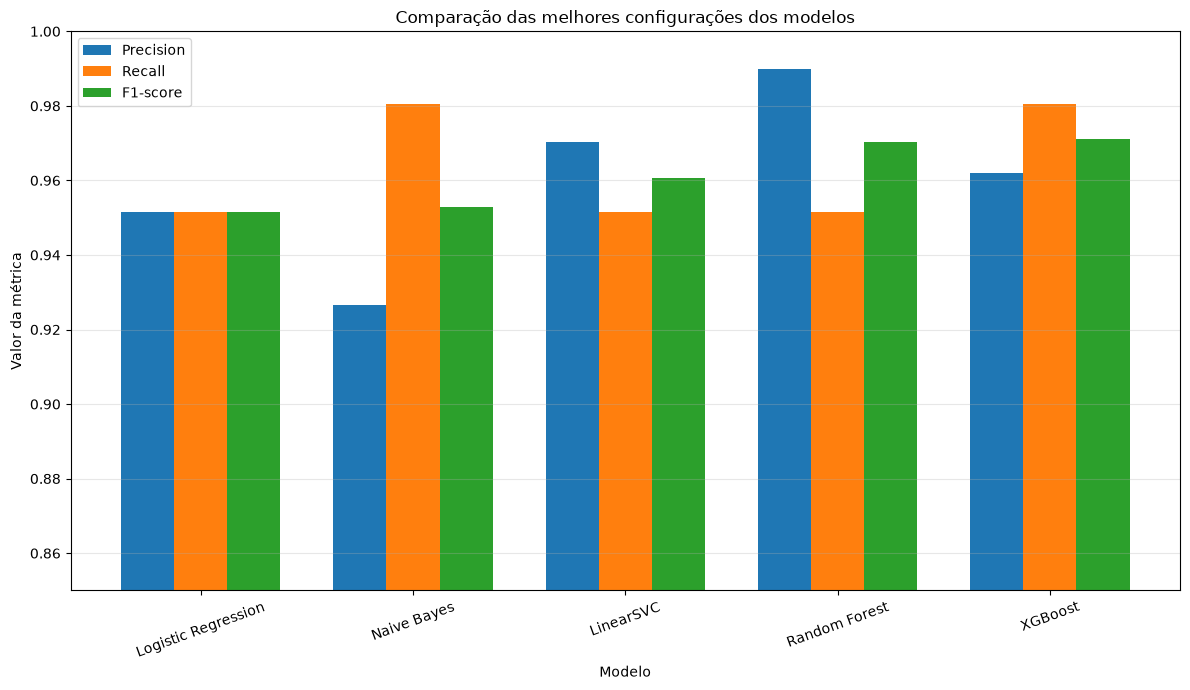

In [24]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Define a posição dos modelos no eixo horizontal.
posicoes_modelos = range(
    len(df_melhores_configuracoes)
)

# Define a largura de cada grupo de barras.
largura_barras = 0.25

# Cria uma nova figura para apresentar a comparação das métricas.
plt.figure(
    figsize=(12, 7)
)

# Cria as barras correspondentes à Precision.
plt.bar(
    [posicao - largura_barras for posicao in posicoes_modelos],
    df_melhores_configuracoes["Precision"],
    width=largura_barras,
    label="Precision"
)

# Cria as barras correspondentes ao Recall.
plt.bar(
    posicoes_modelos,
    df_melhores_configuracoes["Recall"],
    width=largura_barras,
    label="Recall"
)

# Cria as barras correspondentes ao F1-score.
plt.bar(
    [posicao + largura_barras for posicao in posicoes_modelos],
    df_melhores_configuracoes["F1-score"],
    width=largura_barras,
    label="F1-score"
)

# Define os nomes dos modelos no eixo horizontal.
plt.xticks(
    list(posicoes_modelos),
    df_melhores_configuracoes["Modelo"],
    rotation=20
)

# Define o nome do eixo horizontal.
plt.xlabel(
    "Modelo"
)

# Define o nome do eixo vertical.
plt.ylabel(
    "Valor da métrica"
)

# Define o título do gráfico.
plt.title(
    "Comparação das melhores configurações dos modelos"
)

# Define o limite inferior do eixo vertical para facilitar a comparação.
plt.ylim(
    0.85,
    1.00
)

# Exibe a legenda das três métricas.
plt.legend()

# Adiciona uma grade horizontal para facilitar a leitura dos valores.
plt.grid(
    axis="y",
    alpha=0.3
)

# Ajusta automaticamente os elementos da figura.
plt.tight_layout()

# Salva o gráfico na pasta destinada à avaliação dos modelos.
plt.savefig(
    f"{pasta_avaliacao}/comparacao_melhores_configuracoes.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()

Matriz de Confusão do XGBoost com threshold de 30% (MODELO MAIS EQUILIBRADO, baseado no f1 score)

In [25]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Importa a função confusion_matrix para calcular a matriz de confusão.
from sklearn.metrics import confusion_matrix

# Obtém as probabilidades de possível golpe produzidas pelo XGBoost.
probabilidades_xgboost = modelo_xgboost.predict_proba(X_teste_final)[:, 1]

# Converte as probabilidades em classificações utilizando 30% como threshold.
previsoes_xgboost_30 = (probabilidades_xgboost >= 0.30).astype(int)

# Calcula a matriz de confusão comparando os valores reais com as previsões.
matriz_confusao_xgboost = confusion_matrix(
    y_teste,
    previsoes_xgboost_30
)

# Exibe os valores da matriz de confusão.
matriz_confusao_xgboost

array([[163,   4],
       [  2, 101]])

| Realidade              | Modelo disse: NÃO golpe | Modelo disse: POSSÍVEL golpe |
| ---------------------- | ----------------------: | ---------------------------: |
| **NÃO era golpe**      |               **163** ✅ |                     **4** ⚠️ |
| **Era possível golpe** |                 **2** ❌ |                    **101** ✅ |


163 TN → acertos de não golpe
4 FP → falsos alarmes
2 FN → golpes que passaram despercebidos ⚠️
101 TP → possíveis golpes identificados corretamente

Gráfico da Matriz de Confusão

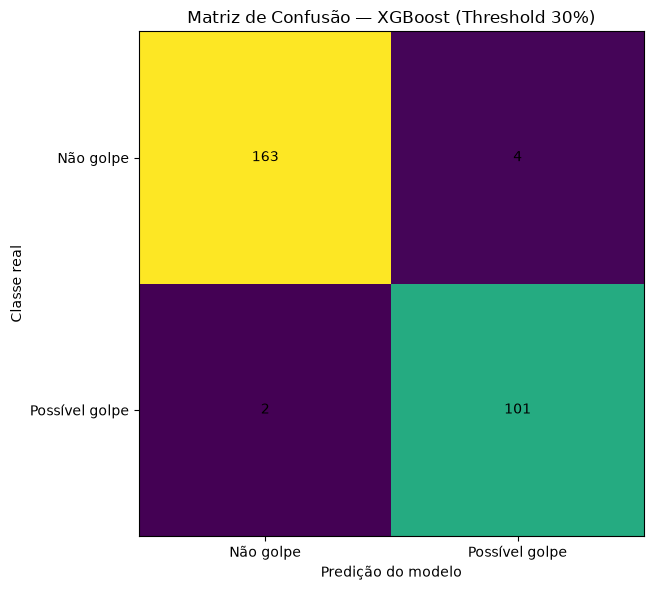

In [26]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Cria uma nova figura para apresentar a matriz de confusão.
plt.figure(figsize=(7, 6))

# Exibe a matriz de confusão como uma imagem.
plt.imshow(matriz_confusao_xgboost)

# Define o título do gráfico.
plt.title("Matriz de Confusão — XGBoost (Threshold 30%)")

# Define o nome do eixo horizontal.
plt.xlabel("Predição do modelo")

# Define o nome do eixo vertical.
plt.ylabel("Classe real")

# Define os rótulos das classes no eixo horizontal.
plt.xticks([0, 1], ["Não golpe", "Possível golpe"])

# Define os rótulos das classes no eixo vertical.
plt.yticks([0, 1], ["Não golpe", "Possível golpe"])

# Percorre as linhas da matriz para adicionar os valores dentro das células.
for linha in range(matriz_confusao_xgboost.shape[0]):

    # Percorre as colunas da matriz para adicionar os valores dentro das células.
    for coluna in range(matriz_confusao_xgboost.shape[1]):

        # Adiciona o valor correspondente no centro de cada célula.
        plt.text(
            coluna,
            linha,
            matriz_confusao_xgboost[linha, coluna],
            ha="center",
            va="center"
        )

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico na pasta de avaliação dos modelos.
plt.savefig(
    f"{pasta_avaliacao}/matriz_confusao_xgboost_threshold_30.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()

Agora vamos analisar os 2 falsos negativos (FN) do XGBoost com threshold de 30%.

localizar os 2 falsos negativos

In [27]:
# Cria uma máscara para localizar as mensagens que eram possíveis golpes, mas foram classificadas como não golpe.
mascara_falsos_negativos = (y_teste == 1) & (previsoes_xgboost_30 == 0)

# Recupera os índices das mensagens classificadas como falsos negativos.
indices_falsos_negativos = y_teste[mascara_falsos_negativos].index

# Exibe os índices das duas mensagens classificadas incorretamente.
indices_falsos_negativos

Index([14, 341], dtype='int64')

Recuperar o texto original dessas duas mensagens.

In [29]:
# Importa a biblioteca Pandas para manipulação dos dados.
import pandas as pd

# Define o caminho do dataset original utilizado no projeto.
caminho_dataset = "../data/raw/DATASET - Dataset_limpo_V1.csv"

# Carrega o dataset original em um DataFrame.
df = pd.read_csv(caminho_dataset)

# Exibe as primeiras linhas para confirmar que o dataset foi carregado corretamente.
df.head()

,Mensagem,solicita_senha,solicita_codigo_autenticacao,solicita_dados_bancarios,solicita_dados_pessoais,solicita_dados_cartao,solicita_atualizacao_cadastro,solicita_pagamento,solicita_clique,solicita_ligacao,...,possui_reembolso,possui_vantagem_inesperada,possui_oferta_financeira,possui_url,possui_url_encurtada,possui_telefone,possui_pix,possui_erros_ortografia_gramatica,possui_chamada_acao,possivel_golpe
0,Sabia que da pra curtir tudo da Claro? 350 MEG...,0,0,0,0,0,0,0,1,1,...,0,0,1,1,1,1,0,1,1,0
1,Seu dia a dia pede MUITA INTERNET! Entao vem p...,0,0,0,0,0,0,0,1,0,...,0,0,1,1,1,0,0,1,1,0
2,"Cliente Claro,nao identificamos pgt fat do ser...",0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,1,0
3,Claro Multi ta na sua com oferta especial: 600...,0,0,0,0,0,0,0,1,1,...,0,0,1,1,1,1,0,1,1,0
4,Claro Multi ta na sua com oferta especial: 600...,0,0,0,0,0,0,0,1,1,...,0,0,1,1,1,1,0,1,1,0


In [31]:
# Recupera as mensagens originais correspondentes aos índices dos falsos negativos.
mensagens_falsos_negativos = df.loc[
    indices_falsos_negativos,
    ["Mensagem", "possivel_golpe"]
]

# Exibe as mensagens que o modelo classificou incorretamente.
mensagens_falsos_negativos

,Mensagem,possivel_golpe
14,[99 Food] Oi da 99Food! Obrigado pela visita! ...,1
341,[Anjun Express]Seu pacote AJ251112106420001 fo...,1


Analisar as características dos falsos negativos

In [32]:
# Define as colunas que representam as características estruturadas das mensagens.
colunas_features_falsos_negativos = [
    "solicita_senha",
    "solicita_codigo_autenticacao",
    "solicita_dados_bancarios",
    "solicita_dados_pessoais",
    "solicita_dados_cartao",
    "solicita_atualizacao_cadastro",
    "solicita_pagamento",
    "solicita_clique",
    "solicita_ligacao",
    "menciona_bloqueio_conta",
    "carga_emocional",
    "possui_urgencia",
    "possui_ameaca",
    "possui_linguagem_alarmista",
    "possui_recompensa",
    "possui_reembolso",
    "possui_vantagem_inesperada",
    "possui_oferta_financeira",
    "possui_url",
    "possui_url_encurtada",
    "possui_telefone",
    "possui_pix",
    "possui_erros_ortografia_gramatica",
    "possui_chamada_acao"
]

# Recupera as características estruturadas das duas mensagens classificadas como falsos negativos.
features_falsos_negativos = df.loc[
    indices_falsos_negativos,
    colunas_features_falsos_negativos
]

# Exibe as características das duas mensagens para análise.
features_falsos_negativos

,solicita_senha,solicita_codigo_autenticacao,solicita_dados_bancarios,solicita_dados_pessoais,solicita_dados_cartao,solicita_atualizacao_cadastro,solicita_pagamento,solicita_clique,solicita_ligacao,menciona_bloqueio_conta,...,possui_recompensa,possui_reembolso,possui_vantagem_inesperada,possui_oferta_financeira,possui_url,possui_url_encurtada,possui_telefone,possui_pix,possui_erros_ortografia_gramatica,possui_chamada_acao
14,0,0,0,0,0,0,0,1,0,0,...,1,0,0,1,1,1,0,0,1,1
341,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


Texto completo

In [34]:
# Configura o Pandas para exibir o conteúdo completo das mensagens sem truncá-las.
pd.set_option("display.max_colwidth", None)

# Exibe somente o texto completo das duas mensagens classificadas como falsos negativos.
df.loc[
    indices_falsos_negativos,
    ["Mensagem", "possivel_golpe"]
]

,Mensagem,possivel_golpe
14,[99 Food] Oi da 99Food! Obrigado pela visita! Guardamos seu presente de boas-vindas: 60% OFF + Frete Gratis! So esta semana. Peca agora>https://dd.me/TbeRJSn,1
341,"[Anjun Express]Seu pacote AJ251112106420001 foi entregue com sucesso e recebido por Caixa de correios,Caixa de correios em seu nome.(11)5026-7008",1


verificar as probabilidades dos dois falsos negativos

In [38]:
# Cria um DataFrame contendo as mensagens classificadas como falsos negativos.
analise_falsos_negativos = df.loc[
    indices_falsos_negativos,
    ["Mensagem", "possivel_golpe"]
].copy()

# Obtém novamente as probabilidades de possível golpe calculadas pelo XGBoost para todo o conjunto de teste.
probabilidades_xgboost_teste = modelo_xgboost.predict_proba(X_teste_final)[:, 1]

# Cria uma Série associando cada probabilidade ao índice original correspondente do conjunto de teste.
serie_probabilidades_xgboost = pd.Series(
    probabilidades_xgboost_teste,
    index=y_teste.index
)

# Adiciona ao DataFrame a probabilidade de possível golpe das mensagens falsamente classificadas.
analise_falsos_negativos["Probabilidade_XGBoost"] = serie_probabilidades_xgboost.loc[
    indices_falsos_negativos
].values

# Adiciona a classificação produzida pelo XGBoost utilizando o threshold de 30%.
analise_falsos_negativos["Previsao_XGBoost_30"] = 0

# Exibe a análise completa dos falsos negativos.
analise_falsos_negativos

,Mensagem,possivel_golpe,Probabilidade_XGBoost,Previsao_XGBoost_30
14,[99 Food] Oi da 99Food! Obrigado pela visita! Guardamos seu presente de boas-vindas: 60% OFF + Frete Gratis! So esta semana. Peca agora>https://dd.me/TbeRJSn,1,0.014766,0
341,"[Anjun Express]Seu pacote AJ251112106420001 foi entregue com sucesso e recebido por Caixa de correios,Caixa de correios em seu nome.(11)5026-7008",1,0.150575,0


Esses dois casos mostram que threshold não resolve todos os erros.

Mesmo diminuindo de 50% para 30%, o modelo continuou classificando essas mensagens como 0 porque suas probabilidades foram:

99Food → 1,48%
Anjun Express → 15,06%

Ou seja, não foram casos simplesmente "quase acertados".

Isso é uma limitação do modelo/dataset que vale muito a pena documentar no projeto.

Importância das features do XGBoost.

In [39]:
# Importa a biblioteca Pandas para organizar os resultados em uma tabela.
import pandas as pd

# Obtém a importância de cada feature utilizada pelo XGBoost.
importancias_features = modelo_xgboost.feature_importances_

# Cria um DataFrame associando cada feature à sua respectiva importância.
df_importancia_features = pd.DataFrame({
    "Feature": dados_preparados["nomes_features"],
    "Importancia": importancias_features
})

# Ordena as features da maior para a menor importância.
df_importancia_features = df_importancia_features.sort_values(
    by="Importancia",
    ascending=False
)

# Seleciona somente as 15 features mais importantes.
df_top_15_features = df_importancia_features.head(15)

# Exibe as 15 features mais importantes do XGBoost.
df_top_15_features

,Feature,Importancia
2861,carga_emocional,0.123216
2237,quero,0.077335
2822,wyden,0.057268
638,bit,0.056870
1313,falar,0.055913
2853,solicita_dados_bancarios,0.042626
1255,estou,0.034374
2870,possui_url_encurtada,0.033264
2864,possui_linguagem_alarmista,0.030546
2643,to,0.030007


Gerar o gráfico

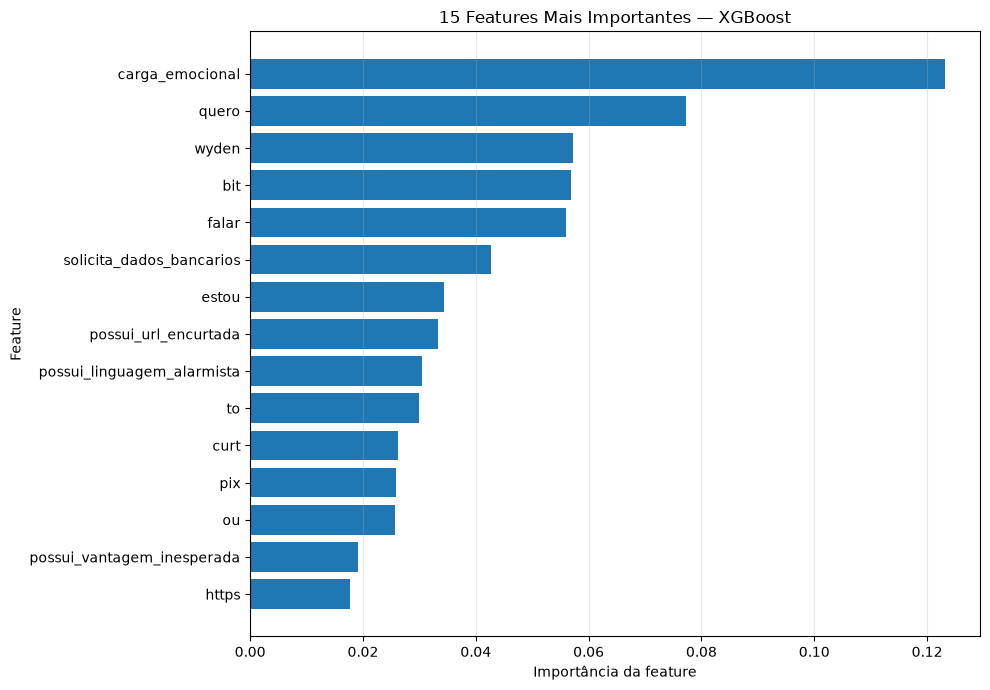

In [40]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Cria uma nova figura para apresentar as quinze features mais importantes.
plt.figure(figsize=(10, 7))

# Cria um gráfico de barras horizontais com as importâncias das features.
plt.barh(
    df_top_15_features["Feature"],
    df_top_15_features["Importancia"]
)

# Inverte a ordem do eixo vertical para colocar a feature mais importante no topo.
plt.gca().invert_yaxis()

# Define o título do gráfico.
plt.title("15 Features Mais Importantes — XGBoost")

# Define o nome do eixo horizontal.
plt.xlabel("Importância da feature")

# Define o nome do eixo vertical.
plt.ylabel("Feature")

# Adiciona uma grade vertical para facilitar a comparação dos valores.
plt.grid(
    axis="x",
    alpha=0.3
)

# Ajusta automaticamente os elementos do gráfico.
plt.tight_layout()

# Salva o gráfico na pasta destinada à avaliação dos modelos.
plt.savefig(
    f"{pasta_avaliacao}/top_15_features_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()

O XGBoost está realmente aprendendo os sinais de risco que definimos ou está dependendo principalmente de palavras específicas?

Separar as features estruturadas

In [41]:
# Cria uma lista contendo somente os nomes das features estruturadas utilizadas no projeto.
features_estruturadas = [
    "solicita_senha",
    "solicita_codigo_autenticacao",
    "solicita_dados_bancarios",
    "solicita_dados_pessoais",
    "solicita_dados_cartao",
    "solicita_atualizacao_cadastro",
    "solicita_pagamento",
    "solicita_clique",
    "solicita_ligacao",
    "menciona_bloqueio_conta",
    "carga_emocional",
    "possui_urgencia",
    "possui_ameaca",
    "possui_linguagem_alarmista",
    "possui_recompensa",
    "possui_reembolso",
    "possui_vantagem_inesperada",
    "possui_oferta_financeira",
    "possui_url",
    "possui_url_encurtada",
    "possui_telefone",
    "possui_pix",
    "possui_erros_ortografia_gramatica",
    "possui_chamada_acao"
]

# Filtra a tabela de importância para manter somente as features estruturadas.
df_importancia_estruturadas = df_importancia_features[
    df_importancia_features["Feature"].isin(features_estruturadas)
].copy()

# Ordena as features estruturadas da maior para a menor importância.
df_importancia_estruturadas = df_importancia_estruturadas.sort_values(
    by="Importancia",
    ascending=False
)

# Exibe todas as features estruturadas ordenadas pela importância.
df_importancia_estruturadas

,Feature,Importancia
2861,carga_emocional,0.123216
2853,solicita_dados_bancarios,0.042626
2870,possui_url_encurtada,0.033264
2864,possui_linguagem_alarmista,0.030546
2867,possui_vantagem_inesperada,0.019034
2874,possui_chamada_acao,0.017392
2860,menciona_bloqueio_conta,0.016903
2854,solicita_dados_pessoais,0.009298
2873,possui_erros_ortografia_gramatica,0.007072
2857,solicita_pagamento,0.005754


Frequência das features estruturadas

In [44]:
# Cria uma lista contendo somente as features estruturadas binárias, excluindo carga_emocional.
features_estruturadas_binarias = [
    feature
    for feature in features_estruturadas
    if feature != "carga_emocional"
]

# Calcula quantas mensagens possuem cada uma das características binárias.
frequencia_features = df[features_estruturadas_binarias].sum().sort_values(
    ascending=False
)

# Converte as frequências calculadas em um DataFrame.
df_frequencia_features = frequencia_features.reset_index()

# Renomeia as colunas para facilitar a interpretação da tabela.
df_frequencia_features.columns = [
    "Feature",
    "Quantidade"
]

# Exibe a frequência de cada característica estruturada binária.
df_frequencia_features

,Feature,Quantidade
0,possui_chamada_acao,847
1,possui_url,579
2,solicita_clique,574
3,possui_erros_ortografia_gramatica,534
4,possui_urgencia,507
5,possui_linguagem_alarmista,406
6,possui_oferta_financeira,285
7,solicita_pagamento,268
8,possui_ameaca,194
9,menciona_bloqueio_conta,191


| Feature                      | Frequência | Importância XGBoost | Interpretação                                        |
| ---------------------------- | ---------: | ------------------: | ---------------------------------------------------- |
| `possui_chamada_acao`        |        847 |              0,0174 | Muito frequente, importância moderada                |
| `possui_url`                 |        579 |              0,0014 | Muito frequente, baixa importância                   |
| `possui_urgencia`            |        507 |              0,0024 | Frequente, baixa importância                         |
| `possui_linguagem_alarmista` |        406 |              0,0305 | Frequente e importante                               |
| `possui_url_encurtada`       |        185 |              0,0333 | Menos frequente, mas muito importante                |
| `possui_vantagem_inesperada` |        157 |              0,0190 | Menos frequente, mas relevante                       |
| `solicita_dados_bancarios`   |     **16** |          **0,0426** | Rara, mas extremamente importante                    |
| `possui_reembolso`           |         18 |              0,0000 | Rara e sem contribuição nos splits                   |
| `solicita_senha`             |         35 |              0,0000 | Rara e sem contribuição nos splits                   |
| `possui_pix`                 |        108 |              0,0000 | Frequência razoável, mas sem contribuição nos splits |


Gráfico das features em relação à ocorrência de possíveis golpes

In [45]:
# Filtra somente as mensagens classificadas como possível golpe.
df_golpes = df[df["possivel_golpe"] == 1]

# Calcula quantas mensagens de possível golpe possuem cada característica estruturada.
frequencia_features_golpes = df_golpes[features_estruturadas_binarias].sum().sort_values(
    ascending=False
)

# Converte as frequências calculadas em um DataFrame.
df_frequencia_golpes = frequencia_features_golpes.reset_index()

# Renomeia as colunas para facilitar a interpretação.
df_frequencia_golpes.columns = [
    "Feature",
    "Quantidade"
]

# Exibe a frequência das features somente nas mensagens de possível golpe.
df_frequencia_golpes

,Feature,Quantidade
0,possui_chamada_acao,502
1,possui_urgencia,406
2,possui_linguagem_alarmista,364
3,solicita_clique,352
4,possui_url,351
5,menciona_bloqueio_conta,187
6,possui_ameaca,187
7,possui_oferta_financeira,164
8,solicita_pagamento,146
9,possui_erros_ortografia_gramatica,142


Gerando gráfico

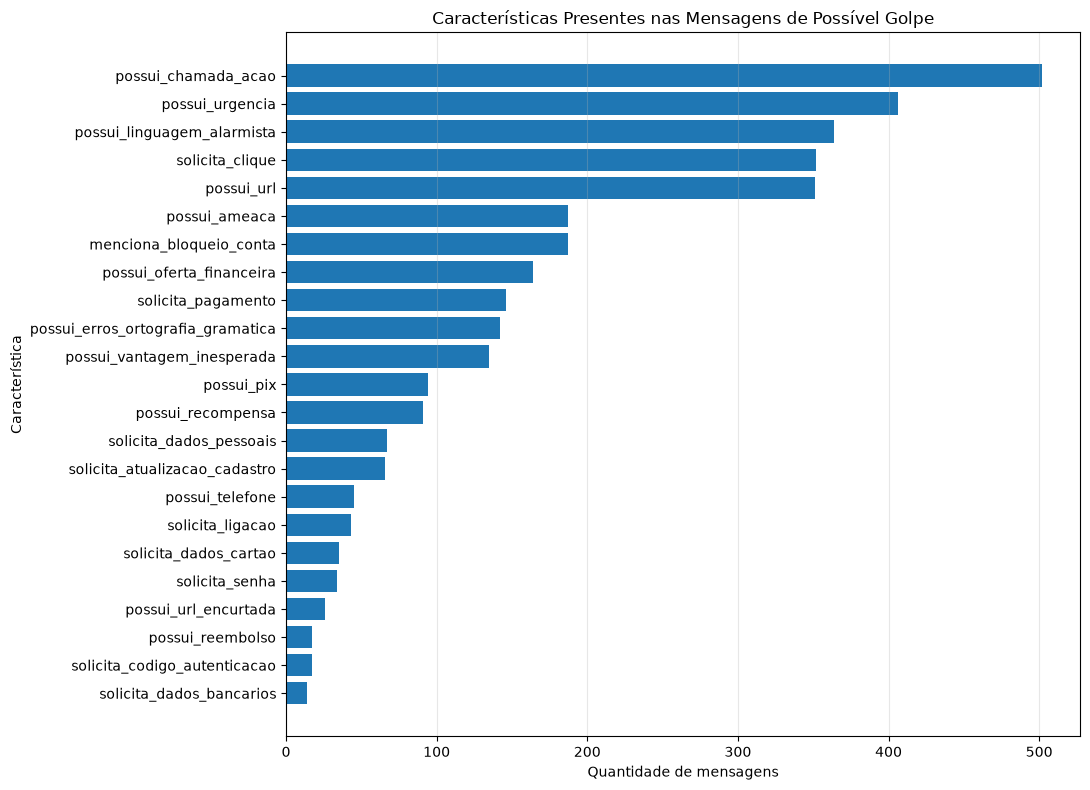

In [46]:
# Importa a biblioteca Matplotlib para criação do gráfico.
import matplotlib.pyplot as plt

# Ordena as features da menor para a maior quantidade para facilitar a criação das barras horizontais.
df_grafico_golpes = df_frequencia_golpes.sort_values(
    by="Quantidade",
    ascending=True
)

# Cria uma nova figura para apresentar a distribuição das features.
plt.figure(figsize=(11, 8))

# Cria um gráfico de barras horizontais com a quantidade de ocorrências de cada feature.
plt.barh(
    df_grafico_golpes["Feature"],
    df_grafico_golpes["Quantidade"]
)

# Define o título do gráfico.
plt.title("Características Presentes nas Mensagens de Possível Golpe")

# Define o nome do eixo horizontal.
plt.xlabel("Quantidade de mensagens")

# Define o nome do eixo vertical.
plt.ylabel("Característica")

# Adiciona uma grade vertical para facilitar a comparação das quantidades.
plt.grid(
    axis="x",
    alpha=0.3
)

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição.
plt.tight_layout()

# Salva o gráfico na pasta destinada aos gráficos de avaliação.
plt.savefig(
    f"{pasta_avaliacao}/features_em_possiveis_golpes.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook.
plt.show()